# Import library

In [69]:
import os
import random
from concurrent.futures import ThreadPoolExecutor
from pathlib import Path
from typing import Any, Dict, Optional

import IPython.display as ipd
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
import soundfile as sf

# Metadata Audio


In [ ]:
def calculate_dataset_metrics(target_path: Path) -> Dict[str, Any]:
    total_bytes = 0
    audio_count = 0
    supported_extensions = {".wav", ".flac"}

    for root, _, files in os.walk(target_path):
        for f in files:
            file_path = os.path.join(root, f)
            try:
                total_bytes += os.path.getsize(file_path)

                if Path(f).suffix.lower() in supported_extensions:
                    audio_count += 1
            except OSError, FileNotFoundError:
                continue

    return {"total_bytes": total_bytes, "audio_count": audio_count}


def probe_audio_metadata(target_path: Path) -> Optional[Dict[str, Any]]:
    try:
        patterns = ["*.wav", "*.flac"]
        sample_file: Optional[Path] = None

        for pattern in patterns:
            sample_file = next(target_path.rglob(pattern), None)
            if sample_file:
                break

        if sample_file is None:
            return None

        info = sf.info(str(sample_file))
        return {
            "samplerate": info.samplerate,
            "channels": info.channels,
            "duration": info.duration,
            "subtype": info.subtype,
            "format": info.format,
        }
    except Exception as e:
        print(f"Error probing audio metadata: {e}")
        return None

In [36]:
def check_folder_structure(target_path: Path) -> bool:
    dataset_path = target_path

    if not dataset_path:
        print("CRITICAL: Dataset directory not found. Verify Google Drive mount point.")

    print(f"Analyzing dataset at: {dataset_path}")

    metrics = calculate_dataset_metrics(dataset_path)

    metadata = probe_audio_metadata(dataset_path)

    print("-" * 50)
    print(f"DATASET METADATA REPORT: {dataset_path.name}")
    print("-" * 50)

    size_gb = metrics["total_bytes"] / (1024**3)
    print(f"Storage Size:        {size_gb:.2f} GB")
    print(f"Total Audio Files:   {metrics['audio_count']:,}")

    if metadata:
        print(f"Sampling Rate:       {metadata['samplerate']} Hz")
        print(f"Bit Depth Subtype:   {metadata['subtype']}")
        print(f"Channel Config:      {metadata['channels']} (Mono/Stereo)")
        print(f"Container Format:    {metadata['format']}")
    else:
        print("Audio Metadata:      Could not retrieve (No valid audio files found)")

    print("-" * 50)

## FSD50K

In [45]:
check_folder_structure(Path("/content/drive/MyDrive/NoiseSuppression/Data/raw/FSD50K"))

Analyzing dataset at: /content/drive/MyDrive/NoiseSuppression/Data/raw/FSD50K
--------------------------------------------------
DATASET METADATA REPORT: FSD50K
--------------------------------------------------
Storage Size:        4.97 GB
Total Audio Files:   6,140
Sampling Rate:       44100 Hz
Bit Depth Subtype:   PCM_16
Channel Config:      1 (Mono/Stereo)
Container Format:    WAV
--------------------------------------------------


## VCTK

In [46]:
check_folder_structure(Path("/content/vctk_temp"))

Analyzing dataset at: /content/vctk_temp
--------------------------------------------------
DATASET METADATA REPORT: vctk_temp
--------------------------------------------------
Storage Size:        10.93 GB
Total Audio Files:   88,328
Sampling Rate:       48000 Hz
Bit Depth Subtype:   PCM_16
Channel Config:      1 (Mono/Stereo)
Container Format:    FLAC
--------------------------------------------------


## Musan

In [47]:
check_folder_structure(Path("/content/drive/MyDrive/NoiseSuppression/Data/raw/musan"))

Analyzing dataset at: /content/drive/MyDrive/NoiseSuppression/Data/raw/musan
--------------------------------------------------
DATASET METADATA REPORT: musan
--------------------------------------------------
Storage Size:        11.73 GB
Total Audio Files:   2,016
Sampling Rate:       16000 Hz
Bit Depth Subtype:   PCM_16
Channel Config:      1 (Mono/Stereo)
Container Format:    WAV
--------------------------------------------------


## AIR/openAIR

In [48]:
check_folder_structure(Path("/content/drive/MyDrive/NoiseSuppression/Data/raw/audb"))

Analyzing dataset at: /content/drive/MyDrive/NoiseSuppression/Data/raw/audb
--------------------------------------------------
DATASET METADATA REPORT: audb
--------------------------------------------------
Storage Size:        2.23 GB
Total Audio Files:   448
Sampling Rate:       48000 Hz
Bit Depth Subtype:   PCM_16
Channel Config:      2 (Mono/Stereo)
Container Format:    WAV
--------------------------------------------------


# Text

In [51]:
from pathlib import Path

LIST_DIR = Path("/content/drive/MyDrive/NoiseSuppression/Data/lists")
MANIFESTS = {
    "Speech (Clean)": "clean_all.txt",
    "Noise & Music": "noise_music.txt",
    "RIR (Room Impulse)": "rir_all.txt",
}

print(f"{'DATASET MANIFEST STATISTICS':^50}\n{'-' * 50}")
print(f"{'Category':<25} | {'File Count':>15}\n{'-' * 50}")

total_count = 0
for label, filename in MANIFESTS.items():
    file_path = LIST_DIR / filename
    if file_path.exists():
        with open(file_path, "r", encoding="utf-8") as f:
            count = sum(1 for _ in f)
        total_count += count
        print(f"{label:<25} | {count:>15,}")
    else:
        print(f"{label:<25} | {'MISSING':>15}")

print(f"{'-' * 50}\n{'AGGREGATE TOTAL':<25} | {total_count:>15,}\n{'-' * 50}")

           DATASET MANIFEST STATISTICS            
--------------------------------------------------
Category                  |      File Count
--------------------------------------------------
Speech (Clean)            |          88,328
Noise & Music             |           6,863
RIR (Room Impulse)        |             448
--------------------------------------------------
AGGREGATE TOTAL           |          95,639
--------------------------------------------------


# Visualize example

In [54]:
def visualize_audio(txt_path, title):
    with open(txt_path, "r") as f:
        all_files = f.read().splitlines()
    random_file = random.choice(all_files)

    print(f"--- {os.path.basename(random_file)} ---")

    y, sr = librosa.load(random_file, sr=48000)
    duration = librosa.get_duration(y=y, sr=sr)

    fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(15, 5))

    librosa.display.waveshow(y, sr=sr, ax=ax[0])
    ax[0].set_title(f"Waveform: {title}")
    ax[0].set_xlabel("Thời gian (s)")

    D = librosa.amplitude_to_db(np.abs(librosa.stft(y)), ref=np.max)
    img = librosa.display.specshow(D, sr=sr, x_axis="time", y_axis="hz", ax=ax[1])
    ax[1].set_title(f"Spectrogram: {title}")
    fig.colorbar(img, ax=ax[1], format="%+2.0f dB")

    plt.tight_layout()
    plt.show()

    print(f"Độ dài: {duration:.2f} giây")
    return y

--- p245_075_mic1.flac ---


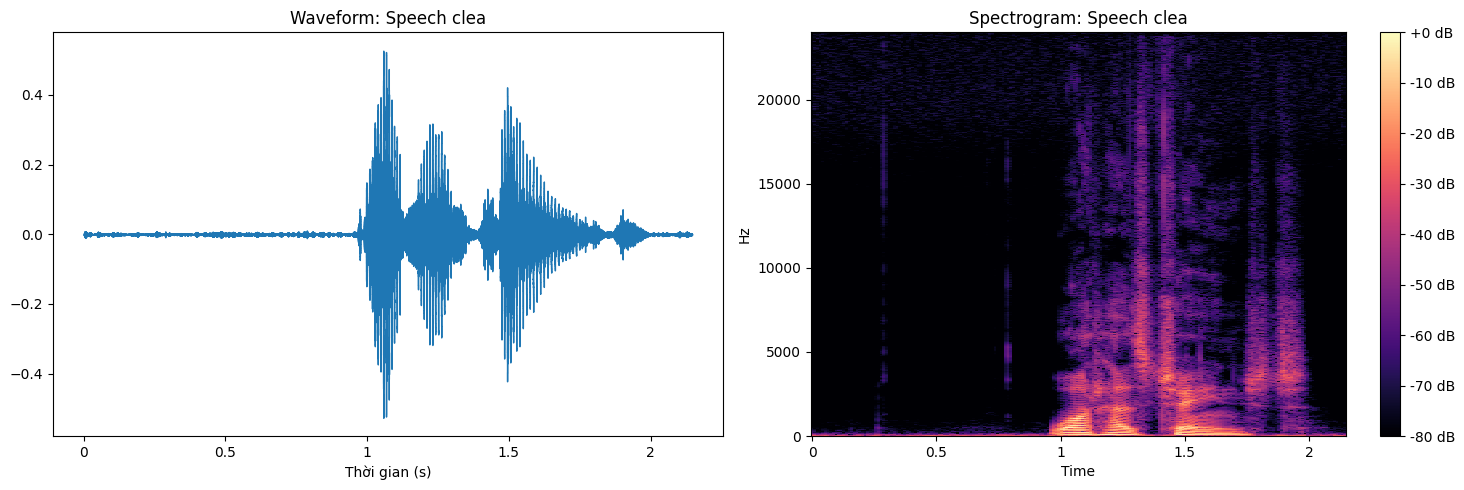

Độ dài: 2.15 giây


In [60]:
speech_txt = "/content/drive/MyDrive/NoiseSuppression/Data/lists/clean_all.txt"

s_audio = visualize_audio(speech_txt, "Speech clea")
ipd.display(ipd.Audio(s_audio, rate=48000))

--- 117241.wav ---


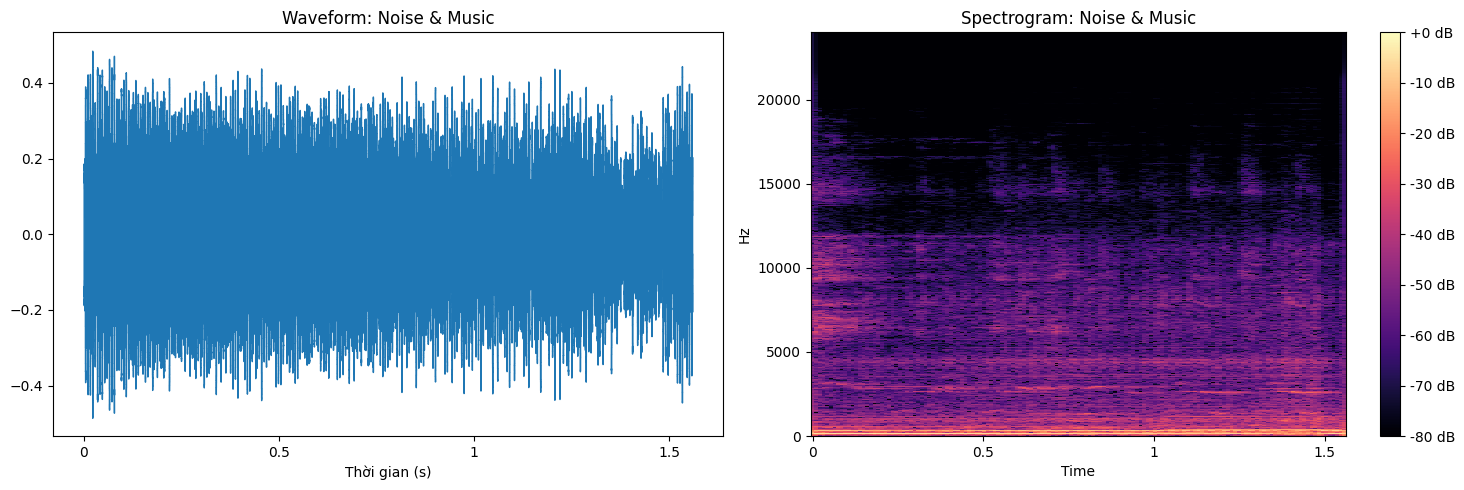

Độ dài: 1.56 giây


In [61]:
noise_txt = "/content/drive/MyDrive/NoiseSuppression/Data/lists/noise_music.txt"
n_audio = visualize_audio(noise_txt, "Noise & Music")
ipd.display(ipd.Audio(n_audio, rate=48000))

--- st_margarets_church_national_centre_early_music__b-format__r11_3rd_configuration.wav ---


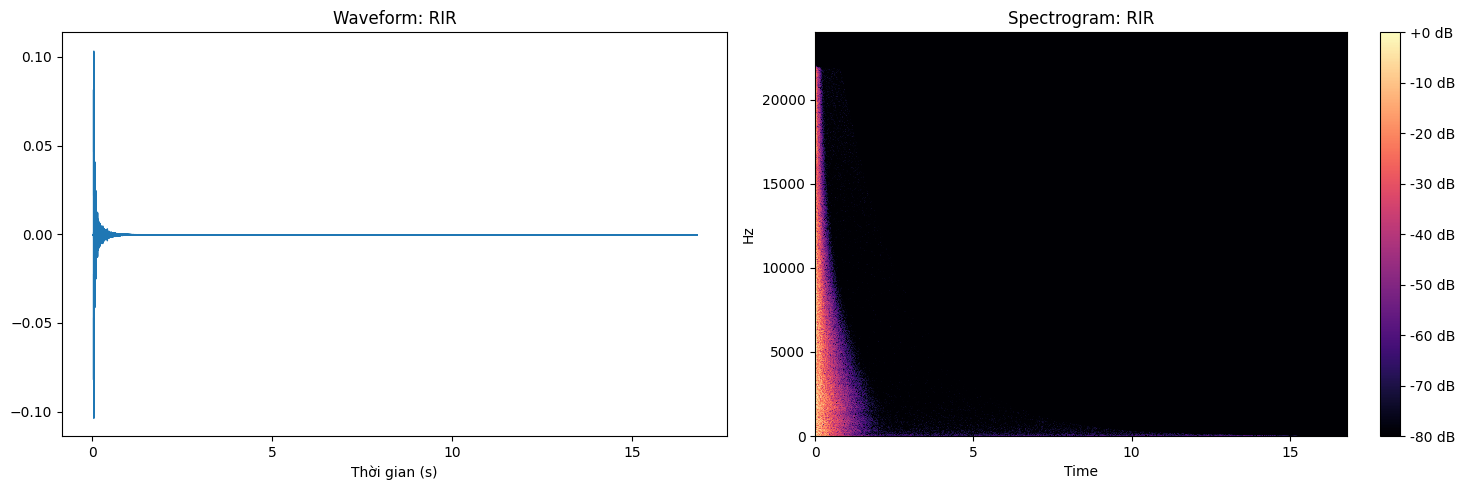

Độ dài: 16.80 giây


In [62]:
noise_txt = "/content/drive/MyDrive/NoiseSuppression/Data/lists/rir_all.txt"
n_audio = visualize_audio(noise_txt, "RIR")
ipd.display(ipd.Audio(n_audio, rate=48000))

# Visualize distribution of data

In [ ]:
def get_audio_duration(file_path):
    try:
        with sf.SoundFile(file_path) as f:
            return len(f) / f.samplerate
    except Exception:
        return None


def process_config(config, n_samples):
    txt_path = config["path"]
    if not os.path.exists(txt_path):
        return None, f"Not found:\n{config['title']}"

    with open(txt_path, "r") as f:
        all_files = f.read().splitlines()

    samples = random.sample(all_files, min(n_samples, len(all_files)))

    with ThreadPoolExecutor(max_workers=20) as executor:
        durations = list(executor.map(get_audio_duration, samples))

    valid_durations = [d for d in durations if d is not None]
    return valid_durations, f"{config['title']}\n({len(all_files):,} files total)"


def plot_combined_distributions(configs, n_samples=100):
    fig, axes = plt.subplots(1, 3, figsize=(22, 6))

    for i, config in enumerate(configs):
        durations, title_text = process_config(config, n_samples)
        ax = axes[i]

        if durations is None or len(durations) == 0:
            ax.set_title(title_text)
            continue

        ax.hist(
            durations,
            bins=40,
            color=config.get("color", "blue"),
            edgecolor="black",
            alpha=0.7,
        )
        ax.set_title(title_text, fontsize=14)
        ax.set_xlabel("Duration (seconds)")
        ax.set_ylabel("Sample Count")
        ax.grid(axis="y", linestyle="--", alpha=0.5)

    plt.tight_layout()
    plt.show()

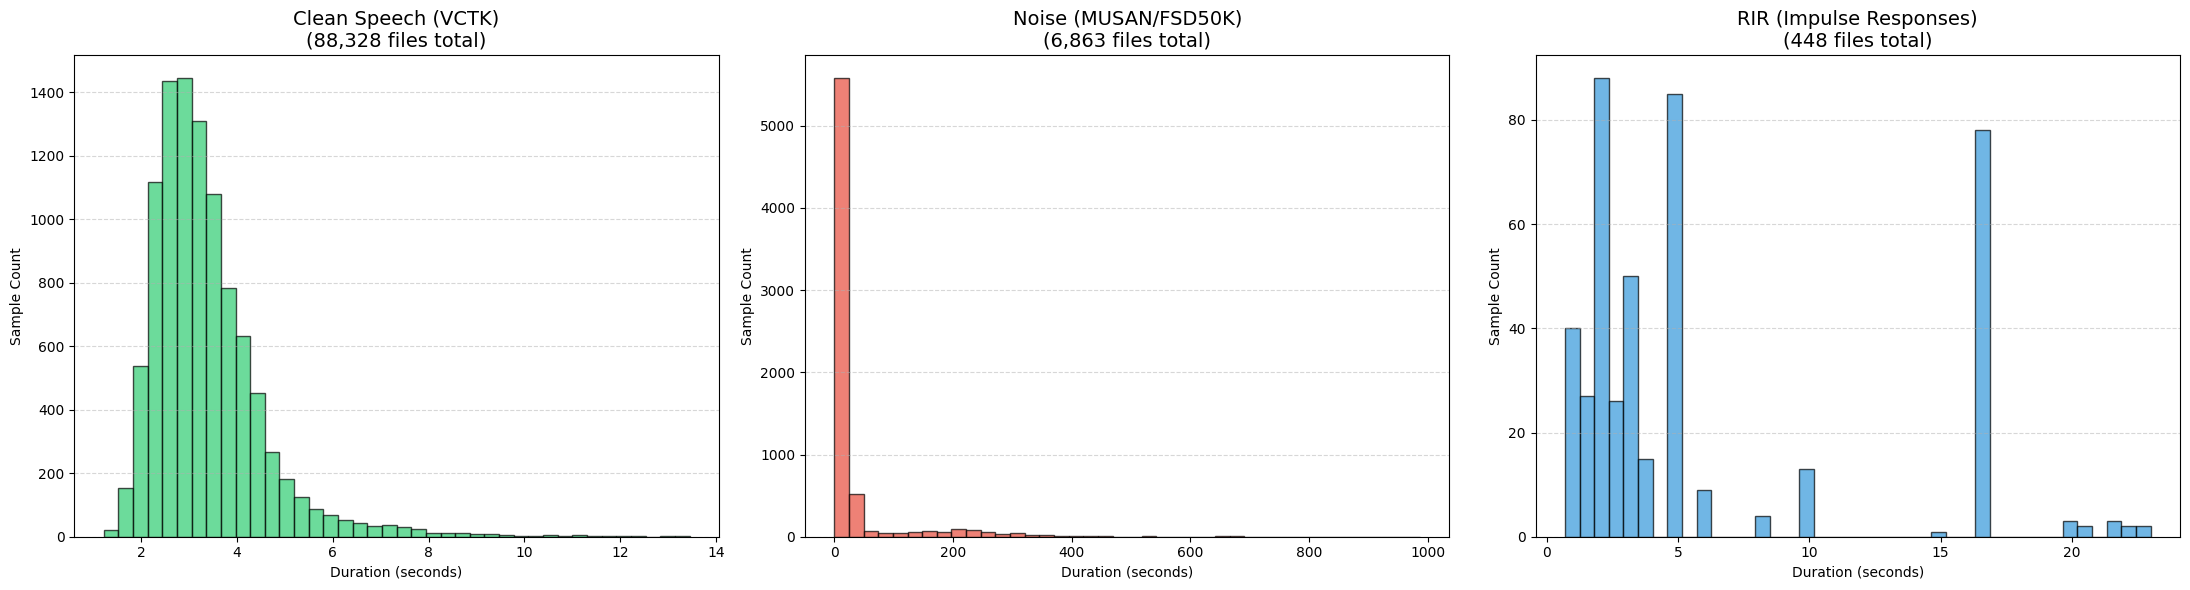

In [73]:
# Example with 10000 samples
speech_txt = "/content/drive/MyDrive/NoiseSuppression/Data/lists/clean_all.txt"
noise_txt = "/content/drive/MyDrive/NoiseSuppression/Data/lists/noise_music.txt"
rir_txt = "/content/drive/MyDrive/NoiseSuppression/Data/lists/rir_all.txt"

dataset_configs = [
    {"path": speech_txt, "title": "Clean Speech (VCTK)", "color": "#2ecc71"},
    {"path": noise_txt, "title": "Noise (MUSAN/FSD50K)", "color": "#e74c3c"},
    {"path": rir_txt, "title": "RIR (Impulse Responses)", "color": "#3498db"},
]

plot_combined_distributions(dataset_configs, n_samples=10000)